Episode 0 | Return: -447.33
Episode 20 | Return: -902.53
Episode 40 | Return: -432.98
Episode 60 | Return: -289.82
Episode 80 | Return: -76.88
Episode 100 | Return: -95.27
Episode 120 | Return: -131.75
Episode 140 | Return: -138.47
Episode 160 | Return: -250.28
Episode 180 | Return: -172.52
Episode 200 | Return: -163.20
Episode 220 | Return: -161.77
Episode 240 | Return: -186.76
Episode 260 | Return: -311.78
Episode 280 | Return: -137.46
Episode 300 | Return: -129.09
Episode 320 | Return: -102.13
Episode 340 | Return: 28.00
Episode 360 | Return: -216.82
Episode 380 | Return: -229.51
Episode 400 | Return: -250.31
Episode 420 | Return: -134.74
Episode 440 | Return: -141.35
Episode 460 | Return: -202.43
Episode 480 | Return: -120.99
Arcsinh transform applied.

Stats:
- Norm. Stdev: 6.7% ± 0.2%
- Entropy: 42.9% ± 17.8%
- Span: 14

Principal Axes:
| Dimension   |    PC1 |   PC2 |   Magnitude |
|:------------|-------:|------:|------------:|
| returns     | -0.484 | 0.864 |       0.991 |
| en

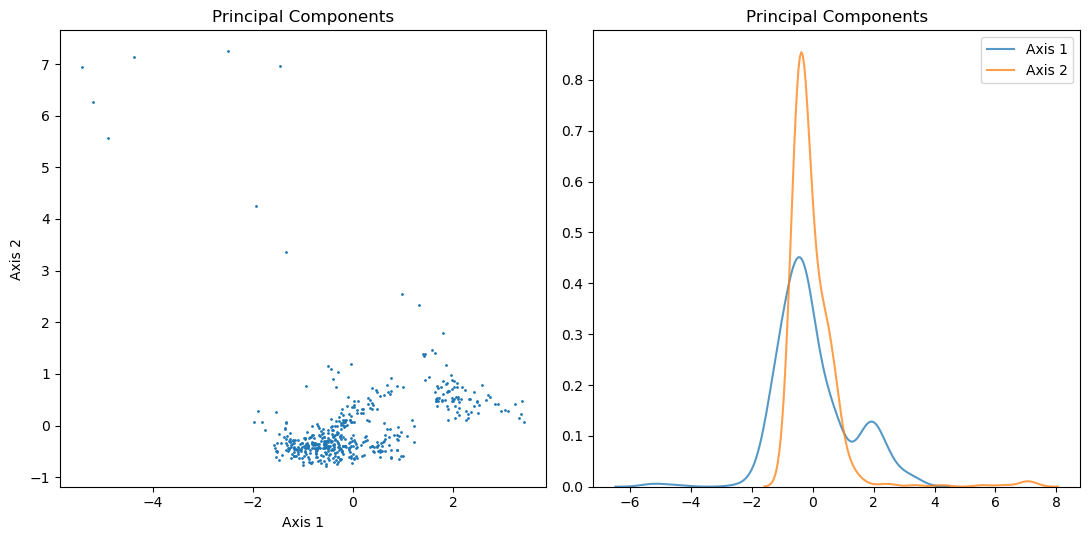

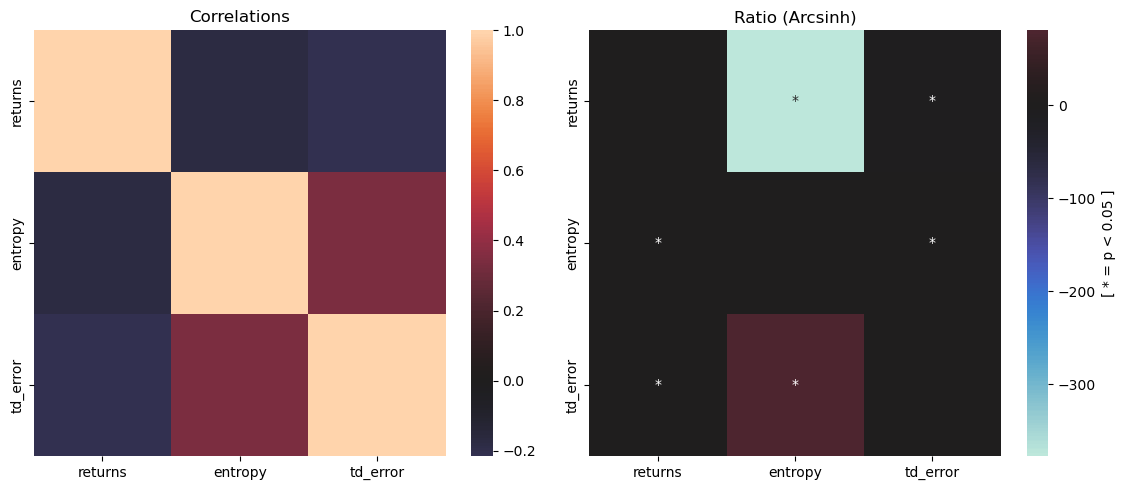

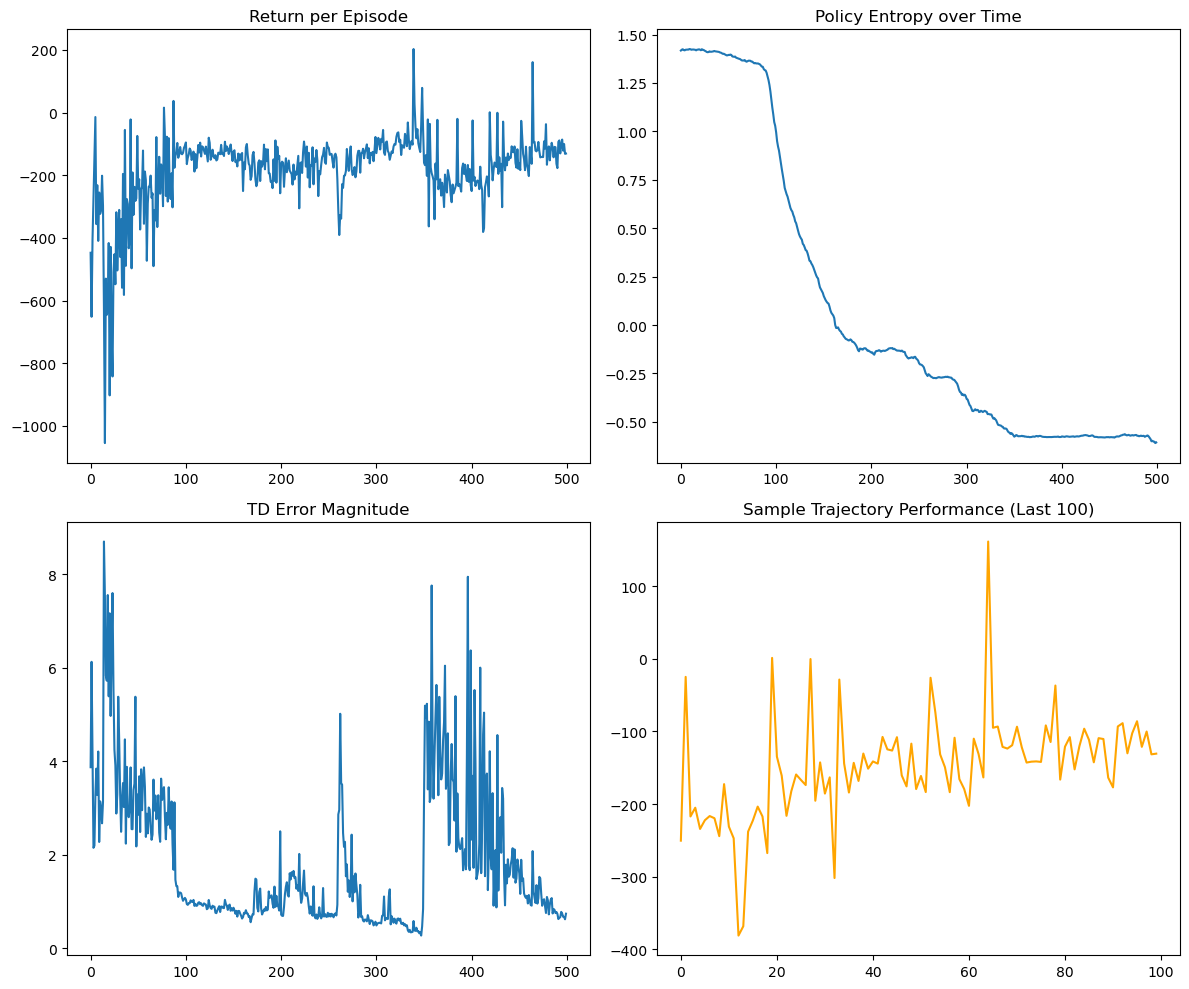

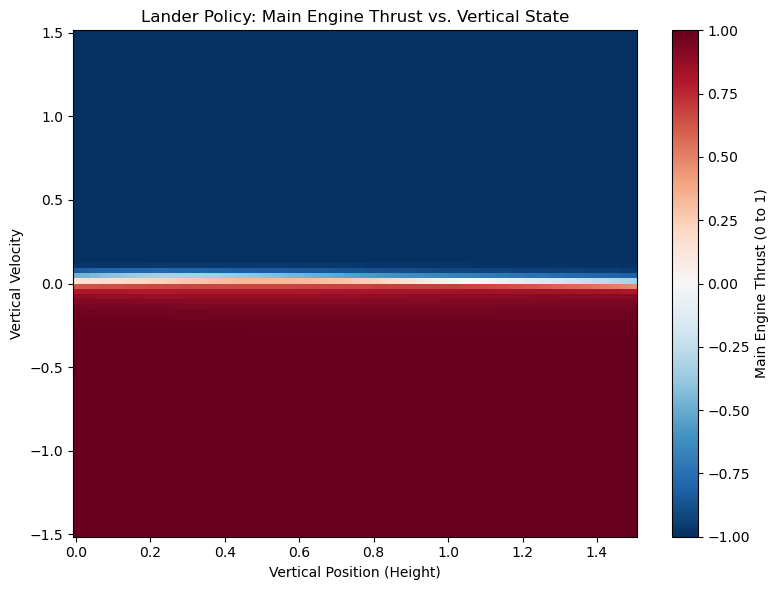

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import hdim_opt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal

# 1. Network Architectures
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), # Added depth for complex physics
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        mu = torch.tanh(self.net(state)) # LunarLander bounds are [-1, 1] natively
        std = torch.exp(self.log_std)
        return mu, std

class Critic(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) # REQUIREMENT: Output state values V(s)
        )

    def forward(self, state):
        return self.net(state)

# --- 2. Setup ---
env = gym.make("LunarLanderContinuous-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# REQUIREMENT: Document hyperparameters
# LR_actor: 3e-4, LR_critic: 1e-3, Gamma: 0.99, Hidden: 128
actor = Actor(env.observation_space.shape[0], env.action_space.shape[0])
critic = Critic(env.observation_space.shape[0])

# REQUIREMENT: Use separate optimizers for actor and critic
actor_opt = optim.Adam(actor.parameters(), lr=3e-4)
critic_opt = optim.Adam(critic.parameters(), lr=1e-3)

# Data for Visualizations
stats = {"returns": [], "entropy": [], "td_error": []}

# --- 3. Training Loop ---
for episode in range(500):
    state, _ = env.reset()
    ep_return, ep_entropy, ep_td = 0, [], []
    done = False
    
    while not done:
        state_t = torch.FloatTensor(state)
        
        # torch.distributions.Normal to create Gaussian
        mu, std = actor(state_t)
        dist = Normal(mu, std)
        
        # Sample actions and compute log probabilities
        action = dist.sample()
        action_clipped = torch.clamp(action, -1.0, 1.0) # Native bounds for LunarLander engines
        log_prob = dist.log_prob(action).sum()
        
        next_state, reward, term, trunc, _ = env.step(action_clipped.detach().numpy())
        done = term or trunc
        next_state_t = torch.FloatTensor(next_state)
        
        # Compute TD Error (Online, TD(0) bootstrapping)
        V_s = critic(state_t)
        with torch.no_grad():
            V_next = critic(next_state_t)
            # delta = reward + gamma * V(next_state) - V(state)
            delta = reward + 0.99 * V_next * (1 - int(term))
        
        td_error = delta - V_s
        
        # Update critic to minimize delta^2 (MSE loss)
        critic_loss = td_error.pow(2).mean()
        critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()
        
        # Update actor using -(log_prob * delta.detach())
        # .detach() to stop gradients through the critic
        actor_loss = -(log_prob * td_error.detach())
        actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()
        
        # Log stats for requirements
        state = next_state
        ep_return += reward
        ep_entropy.append(dist.entropy().mean().item()) # Policy entropy
        ep_td.append(abs(td_error.item())) # TD error magnitude
    
    stats["returns"].append(ep_return)
    stats["entropy"].append(np.mean(ep_entropy))
    stats["td_error"].append(np.mean(ep_td))
    
    if episode % 20 == 0:
        print(f"Episode {episode} | Return: {ep_return:.2f}")


### visualization
# new hdim_opt data analysis function     ####### (dr. busch you should try this on any arbitrary dataset you're working with)
hdim_opt.analyze(stats, transform=True)


# main results
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# return per episode
axs[0, 0].plot(stats['returns'])
axs[0, 0].set_title('Return per Episode')

# policy entropy
axs[0, 1].plot(stats['entropy'])
axs[0, 1].set_title('Policy Entropy over Time')

# sample trajectory of last episode
axs[1, 1].plot(stats['returns'][-100:], color='orange') # reward history
axs[1, 1].set_title('Sample Trajectory Performance (Last 100)')

# TD error
axs[1, 0].plot(stats['td_error'])
axs[1, 0].set_title('TD Error Magnitude')

plt.tight_layout()
plt.savefig('results.png')
plt.show()


### policy map
y_range = np.linspace(0, 1.5, 100)  # vertical position
vy_range = np.linspace(-1.5, 1.5, 100)  # vertical velocity
Y, VY = np.meshgrid(y_range, vy_range)
actions = np.zeros_like(Y)
for i in range(100):
    for j in range(100):
        # 8D state: [x, y, vx, vy, angle, angular_v, leg_l, leg_r]
        # set everything to 0 except two dimensions being plotted
        s = torch.zeros(8) 
        s[1] = y_range[i]   # y position
        s[3] = vy_range[j]  # y velocity
        
        with torch.no_grad():
            mu, _ = actor(s)
            # plotting main engine (index 0) from mu tuple (Main Engine, Side Engines)
            actions[j, i] = mu[0].item() 

# plot policy
plt.figure(figsize=(8, 6))
plt.pcolormesh(Y, VY, actions, cmap="RdBu_r", shading="auto")
plt.colorbar(label="Main Engine Thrust (0 to 1)")
plt.xlabel("Vertical Position (Height)")
plt.ylabel("Vertical Velocity")
plt.title("Lander Policy: Main Engine Thrust vs. Vertical State")

plt.tight_layout()
plt.savefig('policy.png')
plt.show()